In [2]:
# Autoload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
sys.path.append('../')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinSolver
import fcc
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import ray
from tqdm import tqdm
import json

In [4]:
num_workers = 12
ray.init(
    num_cpus=num_workers,
    ignore_reinit_error=True,
    log_to_driver=False,
    runtime_env={
        "py_modules": [fcc],
    },
)

2024-11-04 23:00:59,943	INFO worker.py:1807 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2024-11-04 23:00:59,949	INFO packaging.py:600 -- Creating a file package for local module '/Users/lir9/protein-folding-qc/notebooks/../fcc'.
2024-11-04 23:00:59,955	INFO packaging.py:392 -- Pushing file package 'gcs://_ray_pkg_22f26edded34fef1.zip' (0.19MiB) to Ray cluster...
2024-11-04 23:00:59,956	INFO packaging.py:405 -- Successfully pushed file package 'gcs://_ray_pkg_22f26edded34fef1.zip'.


Python version:,3.12.2
Ray version:,2.38.0
Dashboard:,http://127.0.0.1:8265


In [ ]:
# ray.shutdown()

### Basic routine

In [5]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [19]:
# main_seq = "LHPGAGK" # Zika
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.98)
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))
print(qubit_op)

Highest degree of the polynomial for 0 and 3: 5
Number of qubits:  9
Number of terms:  131
SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIIIZZ', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IIIIZIZZI', 'IIIZIIIZI', 'IIIIZIIZI', 'IIIZZIIZI', 'IIIIIZZZI', 'IIIZIZZZI', 'IIIIZZZZI', 'IIIZZZZZI', 'IIIIIIIIZ', 'IIIZIIIIZ', 'IIIIZIIIZ', 'IIIIIIZIZ', 'IIIZZIZIZ', 'IIIZIZZIZ', 'IIIIZZZIZ', 'IIIIZZIZZ', 'IIIIZIZZZ', 'IIIZIZIZZ', 'IIIZZIIZZ', 'IIIZIIZZZ', 'IIIZIZIIZ', 'IIIZZIIIZ', 'IIIZZZZIZ', 'IIIIIZZIZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IZIIIIIII', 'IZIIIIIZI

Below we incorporate the sampling VQE approach, where we store all the configurations sampled during the VQE optimization. In the end, we choose the top N configurations as the final result and save them in a file.

In [23]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 100
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.02 seconds
 >> Processing 329 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 49 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 56 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 42 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 13 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 7 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 6 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 3 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 0 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 1 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 3 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >>

In [24]:
opt_results

{'final_cost': -18.616013986013932,
 'opt_params': array([10.505797  ,  7.59050722, 11.49763178, 11.20689747,  1.46434821,
         7.67738471,  4.03988899, 11.7494299 ,  5.69597148, 10.4680701 ,
         3.87228217, 10.47168476, 11.33009614,  3.46244989,  3.87417235,
         3.73708293,  2.52048917,  5.86756134]),
 'cost_trajectory': [-11.944376223776192,
  -11.456946153846157,
  -14.466958041957998,
  -12.857661538461496,
  -12.785665734265693,
  -14.280163636363602,
  -16.938131468531424,
  -16.0257636363636,
  -15.057987412587364,
  -11.64453426573422,
  -18.616013986013932,
  -18.616013986013932,
  -18.13004755244752,
  -18.58593846153847,
  -13.921474125874145,
  -18.616013986013932,
  -18.616013986013932,
  -18.616013986013932,
  -11.715881118881073,
  -18.616013986013932,
  -16.72152167832164,
  -18.616013986013932,
  -18.616013986013932,
  -18.24862797202793,
  -18.616013986013932,
  -18.0314545454545,
  -18.279069930069884,
  -18.616013986013932,
  -18.616013986013932,
  -18

In [25]:
from fcc.fcc_protein_shape import ProteinShapeDecoder

best_solution = opt_results["top_solutions"][0][0]
print(best_solution)
shape_decoder = ProteinShapeDecoder(protein_folding_problem.peptide, solution_bitstring=best_solution)
print(shape_decoder.turn_sequence)

101100110
[0, 9, 4]


### How does different R^2 threshold affect the quality of solutions?

In [6]:
shots = 10_000
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 100
num_batches = num_workers

In [7]:
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []

r2_thresholds = [0.95, 0.96, 0.97, 0.98, 0.99, 0.992, 0.994, 0.996, 0.998]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_10_bitstrings = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_bitstrings_list.append(top_10_bitstrings)
    

100%|██████████| 9/9 [00:21<00:00,  2.44s/it]


In [8]:
# We assume that the solutions with the highest r2_threshold are the best ones and compute the number of overlapping solutions with the other threshold values
overlapping_solutions_ratio = []
best_bitstrings = set(top_bitstrings_list[len(r2_thresholds) - 1])
for i in range(len(r2_thresholds) - 1):
    overlaps = best_bitstrings.intersection(top_bitstrings_list[i])
    overlapping_solutions_ratio.append(len(overlaps) / len(best_bitstrings))

print(overlapping_solutions_ratio)


[0.8, 0.8, 0.8, 0.8, 0.95, 0.95, 0.95, 0.95]


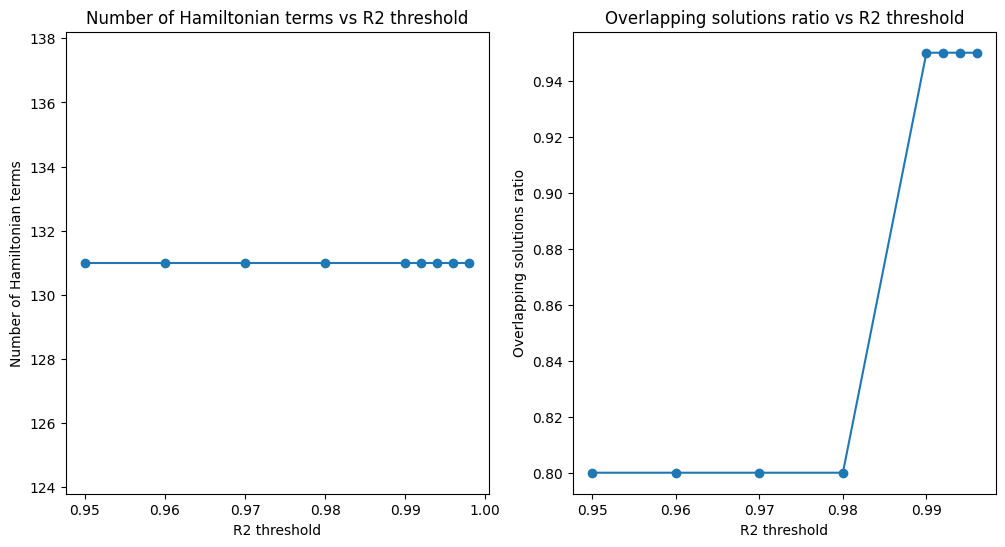

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds) - 1], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()


In [10]:
main_seq = "GNLVS" # 4QXX
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []

r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))
    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()

    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings = [sol[0] for sol in opt_results["top_solutions"][0:50]]
    top_bitstrings_list.append(top_bitstrings)


overlapping_solutions_ratio = []
best_bitstrings = set(top_bitstrings_list[len(r2_thresholds) - 1])
for i in range(len(r2_thresholds) - 1):
    overlaps = best_bitstrings.intersection(top_bitstrings_list[i])
    overlapping_solutions_ratio.append(len(overlaps) / len(best_bitstrings))

print(overlapping_solutions_ratio)
    

100%|██████████| 7/7 [00:25<00:00,  3.60s/it]

[0.06, 0.02, 0.3, 0.52, 0.5, 0.72]


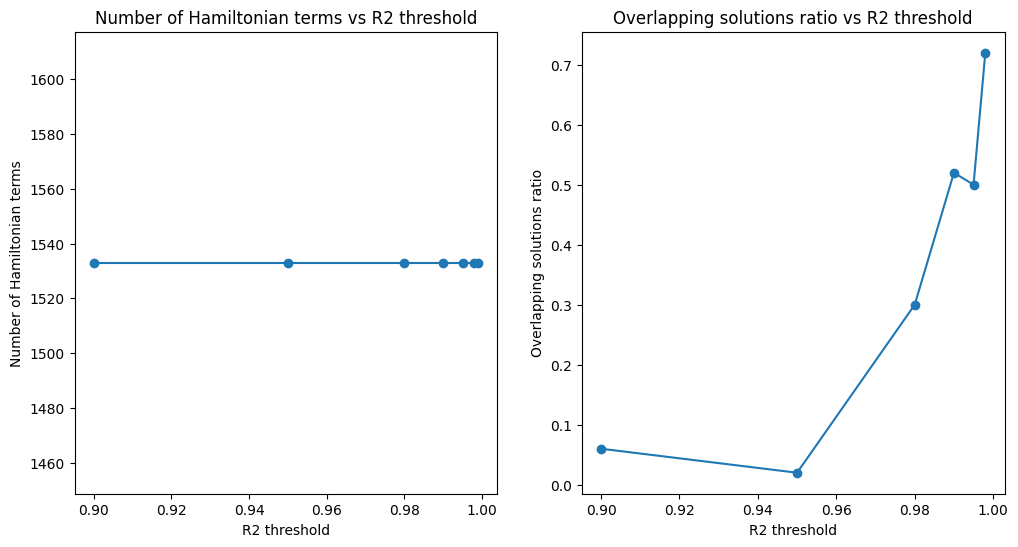

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds) - 1], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()


In [12]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_bitstrings_list = []

r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))
    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()

    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings = [sol[0] for sol in opt_results["top_solutions"][0:50]]
    top_bitstrings_list.append(top_bitstrings)


overlapping_solutions_ratio = []
best_bitstrings = set(top_bitstrings_list[len(r2_thresholds) - 1])
for i in range(len(r2_thresholds) - 1):
    overlaps = best_bitstrings.intersection(top_bitstrings_list[i])
    overlapping_solutions_ratio.append(len(overlaps) / len(best_bitstrings))

print(overlapping_solutions_ratio)
    

100%|██████████| 7/7 [12:24<00:00, 106.30s/it]

[0.0, 0.0, 0.0, 0.0, 0.02, 0.02]


In [15]:
set(top_bitstrings_list[-2]) & set(top_bitstrings_list[-1])

{'111000100111000001001110'}

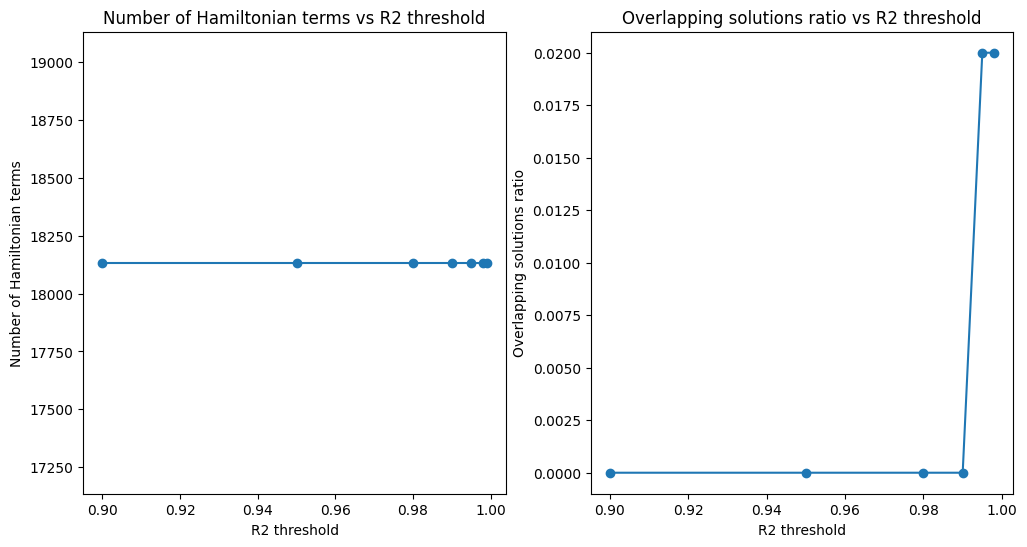

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds) - 1], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()
